# Query Clustering for Intent Discovery in Web Search

**Course:** Information Retrieval (S2-25_AIMLZG537)  
**Assignment:** #1  

**Contents:** 

## Contents

The assignment submission includes:

1. **PDF Report**  
   Generated from a Jupyter Notebook using the backend source code.

2. **Source Code**  
   Provided with the entry point defined in `main.py`.

3. **Outputs**  
   Generated by the source code, stored in the `outputs` folder, and included within this pdf report.
---

## Table of Contents

1. [Problem Statement & Objectives](#1-problem-statement--objectives)
2. [Dataset Overview](#2-dataset-overview)
3. [Query Representations](#3-query-representations)
4. [Clustering Algorithms](#4-clustering-algorithms)
   - 4.1 [K-Means Clustering](#41-k-means-clustering)
   - 4.2 [Hierarchical Clustering](#42-hierarchical-clustering)
   - 4.3 [DBSCAN Clustering](#43-dbscan-clustering)
5. [Text Mining & Cluster Characterization](#5-text-mining--cluster-characterization)
6. [Cluster Stability Analysis](#6-cluster-stability-analysis)
7. [Cross-Lingual Query Clustering](#7-cross-lingual-query-clustering)
8. [Query Suggestion Improvement](#8-query-suggestion-improvement)
9. [Results Summary & Conclusions](#9-results-summary--conclusions)

---

## 1. Problem Statement & Objectives

### Problem Statement

Modern web search systems must understand user intent behind queries. Similar queries often reflect shared intent (e.g., "weather Goa", "temperature in Goa"). This assignment focuses on **query-side intelligence** rather than document retrieval alone.

### Objectives

1. **Represent queries** using appropriate vector representations (TF-IDF, N-grams, LSA)
2. **Apply clustering algorithms** (K-Means, Hierarchical, DBSCAN)
3. **Interpret discovered intent groups** through text mining
4. **Evaluate clustering quality** using silhouette scores and ARI
5. **Explore cross-lingual query clustering** using translation-based normalization

### Key Assumptions

- **Ground-truth labels** are used only for evaluation (ARI), never for training
- All representations are **L2-normalized** for cosine-distance clustering
- **Translation dictionary** is provided for cross-lingual analysis
- Multilingual queries comprise approximately **13% of the corpus**

## Setup & Imports

In [108]:
# Standard library imports
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Configure plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Create output directory
os.chdir("C:/Users/nikita.LAPTOP-FMKC360J/Downloads/assignment1_code")
os.makedirs('outputs', exist_ok=True)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [109]:
# Import project modules
 
from dataset import (
    QUERIES, 
    INTENT_LABELS, 
    LANGUAGE_LABELS,
    TRANSLATIONS, 
    N_TRUE_INTENTS
)

from representations import build_all

from clustering import (
    kmeans_cluster,
    hierarchical_cluster,
    dbscan_cluster,
    experiment_kmeans_k,
    experiment_hierarchical_linkage,
    experiment_dbscan_grid,
    stability_analysis,
    cluster_stats
)

from text_mining import (
    top_terms_per_cluster,
    generate_cluster_label,
    extract_frequent_patterns,
    queries_by_cluster,
    print_cluster_summary
)

from cross_lingual import (
    normalise_corpus,
    language_distribution,
    cross_lingual_comparison,
    multilingual_cluster_membership
)

import visualization_plot as vizp

print("✓ Project modules imported successfully")

✓ Project modules imported successfully


---

## 2. Dataset Overview

The dataset consists of **230 search queries** spanning **10 intent categories**:
- Weather
- Sports/Cricket
- Food/Restaurants
- Travel/Tourism
- Technology/Software
- Health/Medical
- News/Current Affairs
- Shopping/E-commerce
- Education/Learning
- Entertainment/Movies

The corpus includes multilingual queries in **Hindi, Spanish, French, and German** to test cross-lingual clustering capabilities.

In [93]:
# Dataset statistics
lang_dist = language_distribution(LANGUAGE_LABELS)
total_queries = len(QUERIES)
multilingual_count = sum(1 for l in LANGUAGE_LABELS if l != 'en')

print("="*70)
print("  DATASET STATISTICS")
print("="*70)
print(f"  Total queries      : {total_queries}")
print(f"  Multilingual       : {multilingual_count} ({100*multilingual_count/total_queries:.1f}%)")
print(f"  Intent categories  : {N_TRUE_INTENTS}")
print(f"\n  Language breakdown:")
for lang, info in sorted(lang_dist.items()):
    lang_name = {'en': 'English', 'hi': 'Hindi', 'es': 'Spanish', 
                 'fr': 'French', 'de': 'German'}.get(lang, lang)
    print(f"    {lang_name:10s} : {info['count']:3d} queries ({info['pct']:5.1f}%)")

# Sample queries from each language
print(f"\n  Sample queries:")
for lang in ['en', 'hi', 'es', 'fr', 'de']:
    samples = [q for q, l in zip(QUERIES, LANGUAGE_LABELS) if l == lang][:2]
    lang_name = {'en': 'English', 'hi': 'Hindi', 'es': 'Spanish', 
                 'fr': 'French', 'de': 'German'}[lang]
    print(f"\n    {lang_name}:")
    for q in samples:
        print(f"      • {q}")

  DATASET STATISTICS
  Total queries      : 230
  Multilingual       : 30 (13.0%)
  Intent categories  : 10

  Language breakdown:
    German     :   7 queries (  3.0%)
    English    : 200 queries ( 87.0%)
    Spanish    :   7 queries (  3.0%)
    French     :   6 queries (  2.6%)
    Hindi      :  10 queries (  4.3%)

  Sample queries:

    English:
      • weather in Mumbai today
      • temperature in Delhi

    Hindi:
      • आज मौसम कैसा है
      • दिल्ली में बारिश होगी क्या

    Spanish:
      • tiempo en Barcelona hoy
      • mejor restaurante cerca de mi

    French:
      • météo Paris aujourd'hui prévisions
      • meilleurs restaurants à Paris

    German:
      • Wetter Berlin heute Vorhersage
      • beste Restaurants in München


---

## 3. Query Representations

We implement **three distinct representation strategies** to capture different aspects of query semantics:

### 3.1 TF-IDF (Word-level)
- **Features:** Unigrams + bigrams (max 8000 features)
- **Reduction:** Truncated SVD to 100 dimensions
- **Normalization:** L2-normalized for cosine distance
- **Use case:** Captures lexical similarity and exact word matches

### 3.2 Character N-grams
- **Features:** Character 2-4 grams (max 15000 features)
- **Reduction:** Truncated SVD to 100 dimensions
- **Normalization:** L2-normalized
- **Use case:** Language-agnostic; handles multilingual text and typos

### 3.3 LSA (Latent Semantic Analysis)
- **Method:** SVD on word TF-IDF matrix
- **Dimensions:** 50 latent components
- **Normalization:** L2-normalized
- **Use case:** Captures latent semantic topics beyond exact matches

All representations are L2-normalized to enable cosine-distance-based clustering.

In [94]:
print("="*70)
print("  BUILDING QUERY REPRESENTATIONS")
print("="*70)

# Build all three representations
# Returns: {name: (X_dense, X_sparse, vectorizer)}
representations = build_all(QUERIES)

print("\n  Summary:")
for rep_name, (X_dense, X_sparse, vectorizer) in representations.items():
    print(f"\n    {rep_name}:")
    print(f"      Dense shape  : {X_dense.shape}")
    if X_sparse is not None:
        print(f"      Sparse shape : {X_sparse.shape}")
    print(f"      Normalized   : Yes (L2)")

print("\n  ✓ All representations built successfully")

  BUILDING QUERY REPRESENTATIONS
[1/3] Building word TF-IDF representation …
    TF-IDF: shape (230, 1026) → dense (230, 100)
[2/3] Building character N-gram TF-IDF representation …
    N-gram: shape (230, 4595) → dense (230, 100)
[3/3] Building LSA semantic embeddings …
    LSA: 50 components explain 42.3% of variance
    LSA: dense shape (230, 50)

  Summary:

    TF-IDF:
      Dense shape  : (230, 100)
      Sparse shape : (230, 1026)
      Normalized   : Yes (L2)

    N-gram:
      Dense shape  : (230, 100)
      Sparse shape : (230, 4595)
      Normalized   : Yes (L2)

    LSA:
      Dense shape  : (230, 50)
      Sparse shape : (230, 1026)
      Normalized   : Yes (L2)

  ✓ All representations built successfully


---

## 4. Clustering Algorithms

We apply three clustering algorithms with comprehensive hyperparameter experimentation:

1. **K-Means:** Partition-based, requires k specification
2. **Hierarchical:** Agglomerative with different linkage strategies
3. **DBSCAN:** Density-based, discovers clusters automatically

For each algorithm, we:
- Experiment with hyperparameters
- Evaluate using silhouette scores
- Compare against ground-truth using Adjusted Rand Index (ARI)
- Visualize clusters using t-SNE

### 4.1 K-Means Clustering

**Hyperparameter Sweep:** We sweep k from 2 to 15 to find the optimal number of clusters for each representation.

  K-MEANS: HYPERPARAMETER SWEEP (k = 2 to 15)

  TF-IDF:
    Best k = 14 (silhouette = 0.0868)
    Top 3 configurations:
      k=14  →  silhouette=0.0868
      k=15  →  silhouette=0.0800
      k=13  →  silhouette=0.0784

  N-gram:
    Best k = 15 (silhouette = 0.0701)
    Top 3 configurations:
      k=15  →  silhouette=0.0701
      k=14  →  silhouette=0.0700
      k=13  →  silhouette=0.0632

  LSA:
    Best k = 14 (silhouette = 0.1630)
    Top 3 configurations:
      k=14  →  silhouette=0.1630
      k=15  →  silhouette=0.1567
      k=13  →  silhouette=0.1421

  ✓ Saved plot: outputs\01_kmeans_sensitivity.png


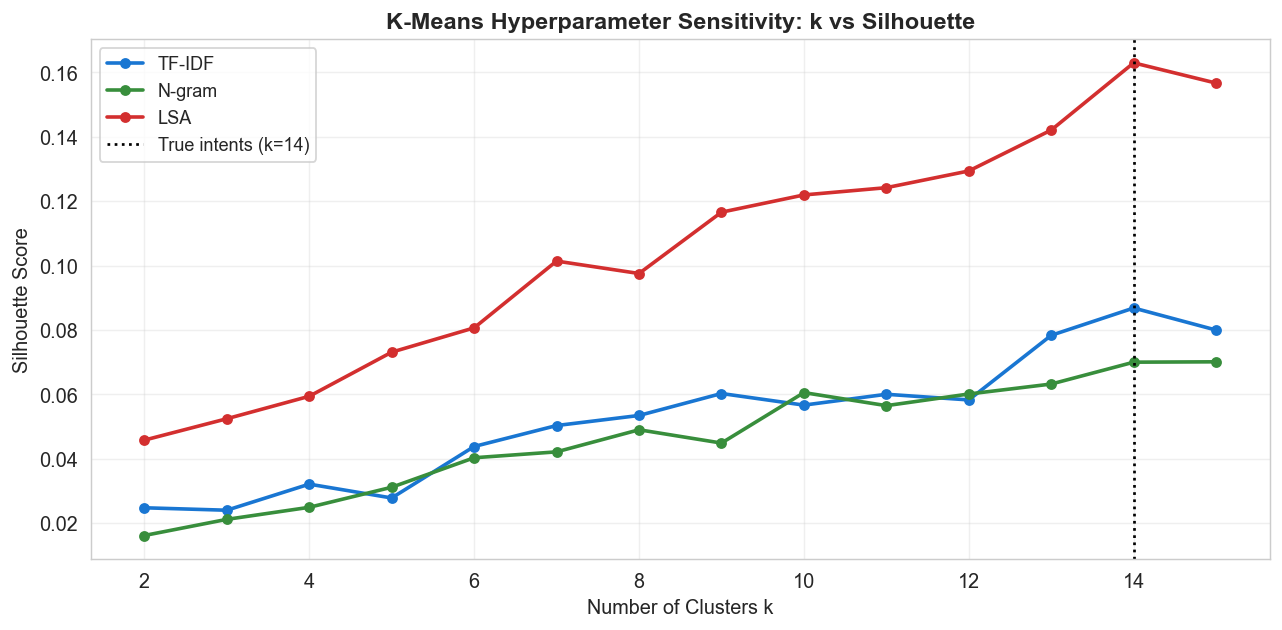

In [118]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

print("="*70)
print("  K-MEANS: HYPERPARAMETER SWEEP (k = 2 to 15)")
print("="*70)

k_results = {}
best_k = {}

# Sweep k for each representation
for rep_name, (X_dense, _, _) in representations.items():
    results = experiment_kmeans_k(X_dense, k_range=range(2, 16))
    k_results[rep_name] = results
    
    # Find best k
    best_entry = max(results, key=lambda r: r['silhouette'])
    best_k[rep_name] = best_entry['k']
    
    print(f"\n  {rep_name}:")
    print(f"    Best k = {best_entry['k']} (silhouette = {best_entry['silhouette']:.4f})")
    print(f"    Top 3 configurations:")
    top3 = sorted(results, key=lambda r: r['silhouette'], reverse=True)[:3]
    for r in top3:
        print(f"      k={r['k']:2d}  →  silhouette={r['silhouette']:.4f}")

# Visualize k sensitivity
plot_path = vizp.plot_k_sensitivity(k_results, '01_kmeans_sensitivity.png', 
                                    true_k=14)
print(f"\n  ✓ Saved plot: {plot_path}")

# Display the plot inline
from IPython.display import Image, display
display(Image(filename=plot_path))

#### K-Means: Final Clustering Results

Using the optimal k for each representation, we perform final clustering and evaluate:

In [119]:
print("="*70)
print("  K-MEANS: FINAL CLUSTERING (best k per representation)")
print("="*70)

kmeans_labels = {}
results_log = []

for rep_name, (X_dense, X_sparse, vectorizer) in representations.items():
    k = best_k[rep_name]
    labels, model = kmeans_cluster(X_dense, k=k)
    kmeans_labels[rep_name] = labels
    
    # Compute metrics
    sil = silhouette_score(X_dense, labels)
    ari = adjusted_rand_score(INTENT_LABELS, labels)
    stats = cluster_stats(labels)
    
    print(f"\n  {rep_name} (k={k}):")
    print(f"    Silhouette Score  : {sil:.4f}")
    print(f"    ARI vs ground-truth: {ari:.4f}")
    print(f"    Number of clusters : {stats['n_clusters']}")
    print(f"    Avg cluster size   : {stats['avg_size']:.1f} ± {stats['std_size']:.1f}")
    
    # Log results
    results_log.append({
        'Method': 'K-Means',
        'Representation': rep_name,
        'Params': f'k={k}',
        'Silhouette': round(sil, 4),
        'ARI': round(ari, 4)
    })
    
    # Generate visualizations
    # 1. t-SNE visualization
    tsne_path = viz.plot_tsne(
        X_dense, labels,
        f'K-Means Clustering (k={k}) — {rep_name}',
        f'02_tsne_kmeans_{rep_name.lower()}.png',
        language_labels=LANGUAGE_LABELS
    )
    
    # 2. Cluster sizes
    sizes_path = viz.plot_cluster_sizes(
        labels,
        f'K-Means Cluster Sizes — {rep_name} (k={k})',
        f'03_cluster_sizes_kmeans_{rep_name.lower()}.png'
    )
    
    # 3. Silhouette analysis
    sil_path = viz.plot_silhouette_analysis(
        X_dense, labels,
        f'Silhouette Analysis — K-Means {rep_name}',
        f'04_silhouette_kmeans_{rep_name.lower()}.png'
    )

print("\n  ✓ Generated t-SNE, cluster size, and silhouette plots")

  K-MEANS: FINAL CLUSTERING (best k per representation)

  TF-IDF (k=14):
    Silhouette Score  : 0.0868
    ARI vs ground-truth: 0.0121
    Number of clusters : 14
    Avg cluster size   : 16.4 ± 42.4

  N-gram (k=15):
    Silhouette Score  : 0.0701
    ARI vs ground-truth: 0.0958
    Number of clusters : 15
    Avg cluster size   : 15.3 ± 13.6

  LSA (k=14):
    Silhouette Score  : 0.1630
    ARI vs ground-truth: 0.0412
    Number of clusters : 14
    Avg cluster size   : 16.4 ± 33.0

  ✓ Generated t-SNE, cluster size, and silhouette plots


## Interpretation

LSA significantly outperforms both TF-IDF and N-gram representations. The higher silhouette scores indicate better-defined and more compact clusters. 

- The optimal number of clusters across all representations consistently falls in the range of **k = 13 to 15**, suggesting a stable estimate of underlying query intents.
- **LSA is the best-performing representation**, demonstrating the importance of capturing latent semantics in text clustering tasks.
- **TF-IDF and N-gram representations struggle** due to high dimensionality and sparsity, leading to weaker cluster separation.

For query intent discovery, **LSA combined with K-Means (k ~ 14)** provides the most meaningful clustering results. This highlights the value of dimensionality reduction techniques in improving clustering quality for textual data.


  K-MEANS: t-SNE VISUALIZATIONS


TF-IDF:


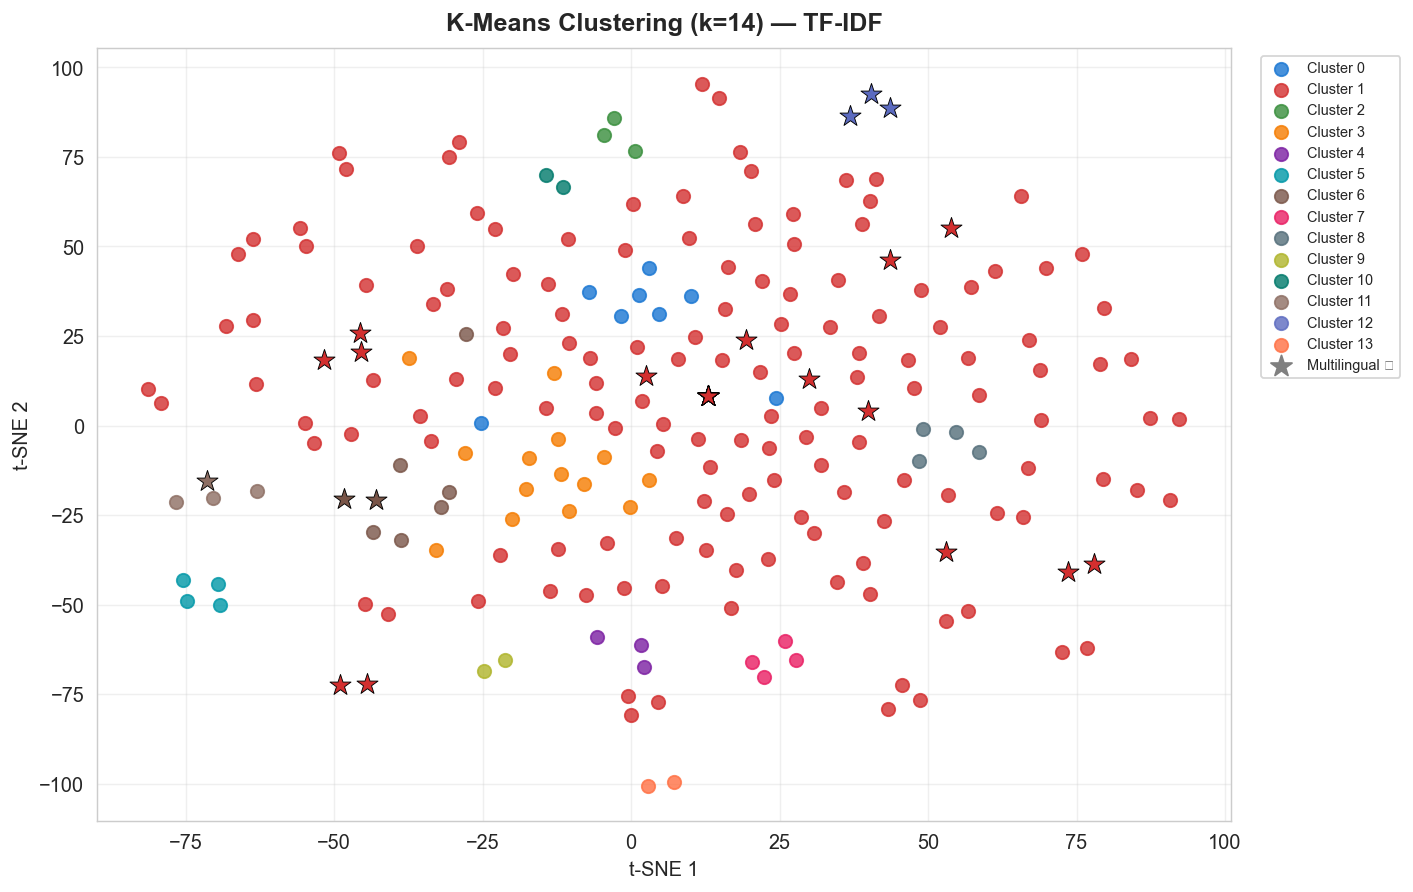


N-gram:


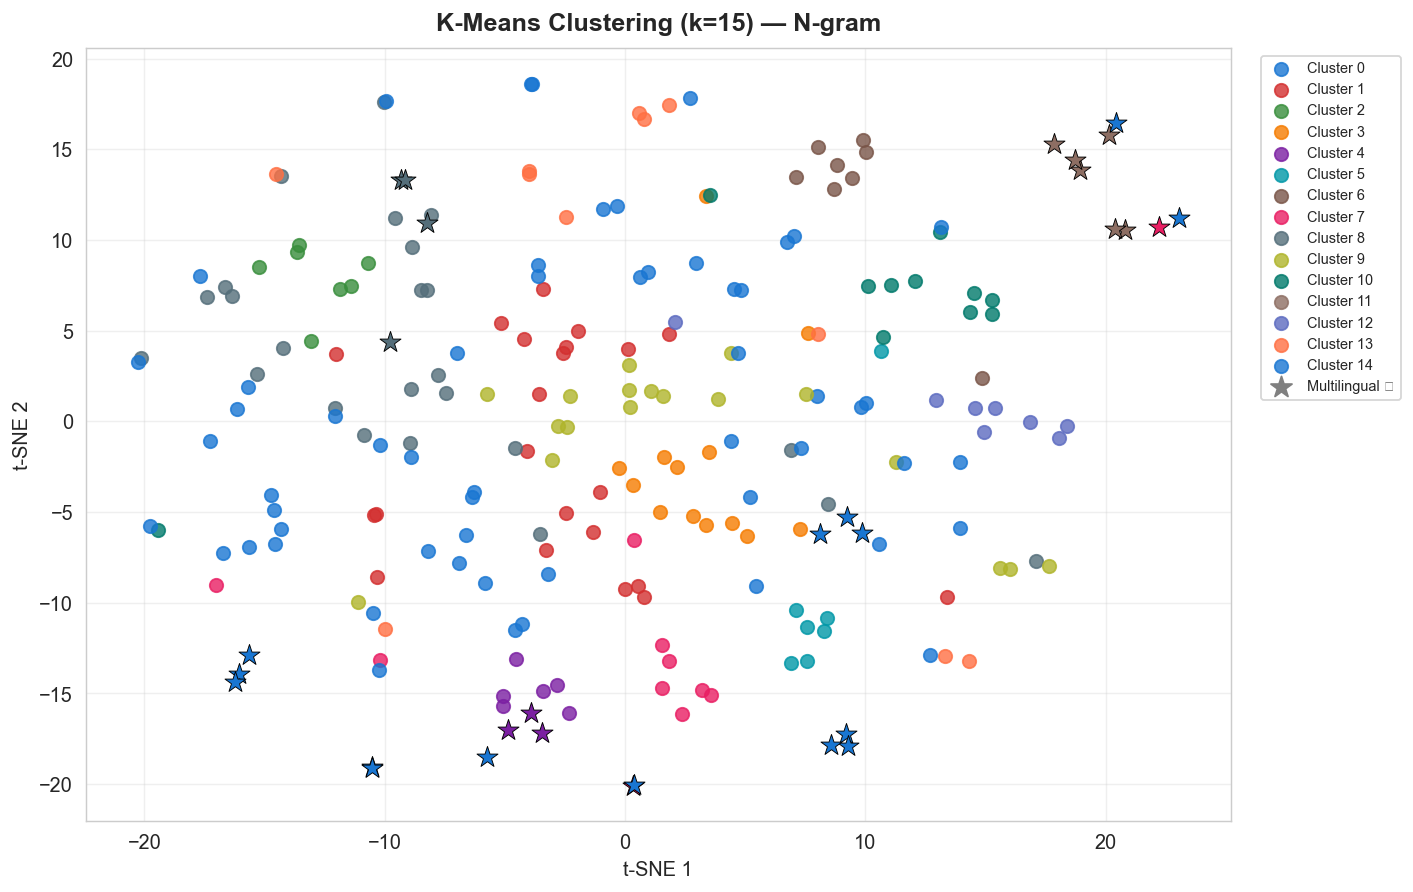


LSA:


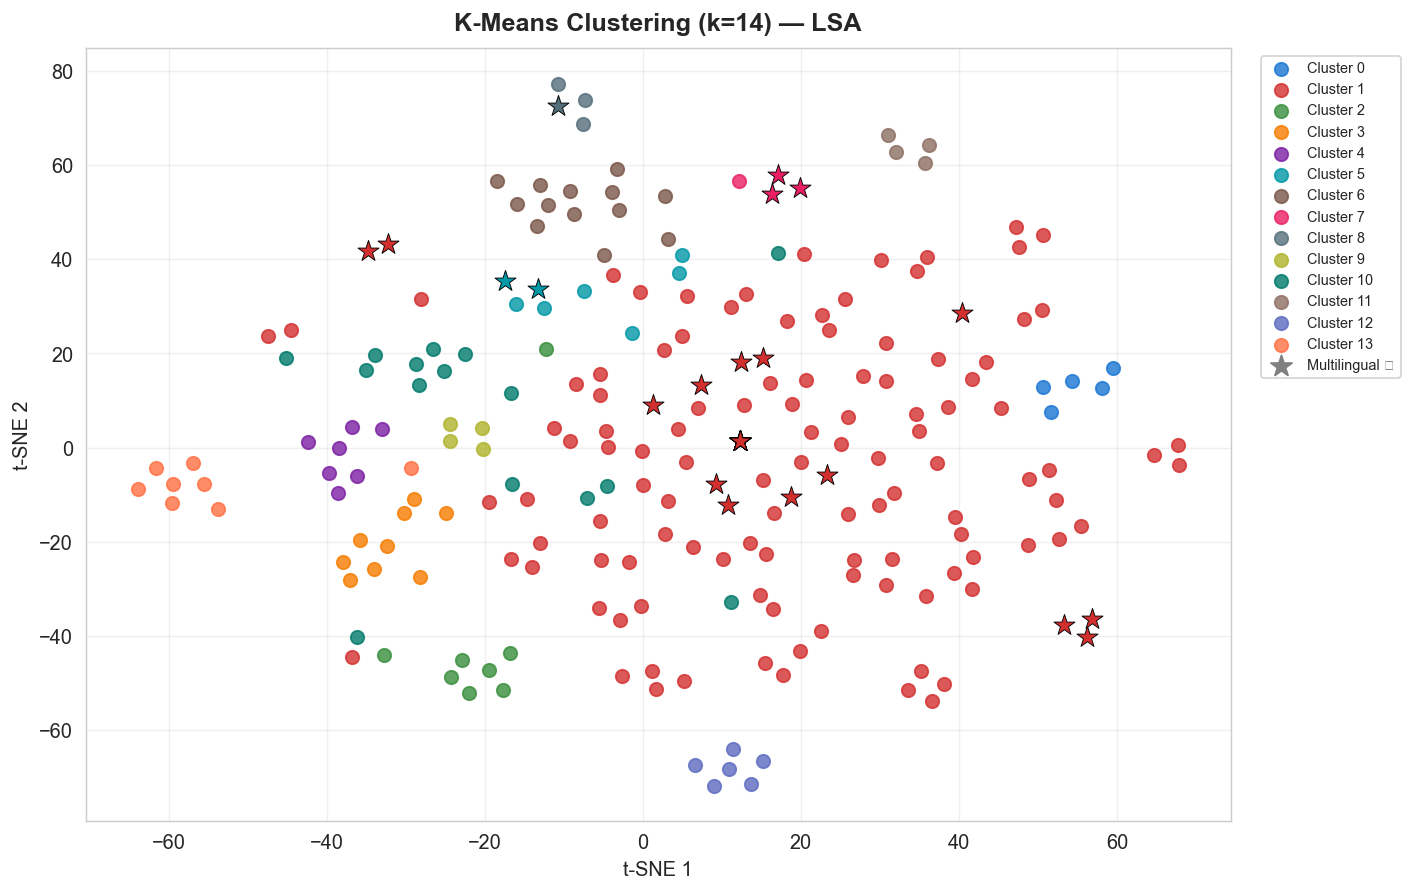

In [120]:
# Display t-SNE plots for each representation
print("\n" + "="*70)
print("  K-MEANS: t-SNE VISUALIZATIONS")
print("="*70 + "\n")

for rep_name in representations.keys():
    img_path = f'outputs/02_tsne_kmeans_{rep_name.lower()}.png'
    if os.path.exists(img_path):
        print(f"\n{rep_name}:")
        display(Image(filename=img_path, width=800))

### 4.2 Hierarchical Clustering

**Linkage Strategy Comparison:** We test three linkage methods:
- **Ward:** Minimizes within-cluster variance (best for balanced clusters)
- **Complete:** Maximum distance between clusters (compact clusters)
- **Average:** Average distance between clusters (balanced approach)

  HIERARCHICAL CLUSTERING: LINKAGE COMPARISON

  TF-IDF (n_clusters=14):
    Best linkage: ward (silhouette=0.0823)
    All linkages:
      ward       → silhouette=0.0823
      complete   → silhouette=-0.0830
      average    → silhouette=0.0328

  N-gram (n_clusters=15):
    Best linkage: ward (silhouette=0.0663)
    All linkages:
      ward       → silhouette=0.0663
      complete   → silhouette=0.0290
      average    → silhouette=0.0508

  LSA (n_clusters=14):
    Best linkage: ward (silhouette=0.1492)
    All linkages:
      ward       → silhouette=0.1492
      complete   → silhouette=0.0323
      average    → silhouette=0.1210

  ✓ Saved linkage comparison: outputs\05_linkage_comparison.png
  ✓ Saved dendrogram: outputs\06_dendrogram.png


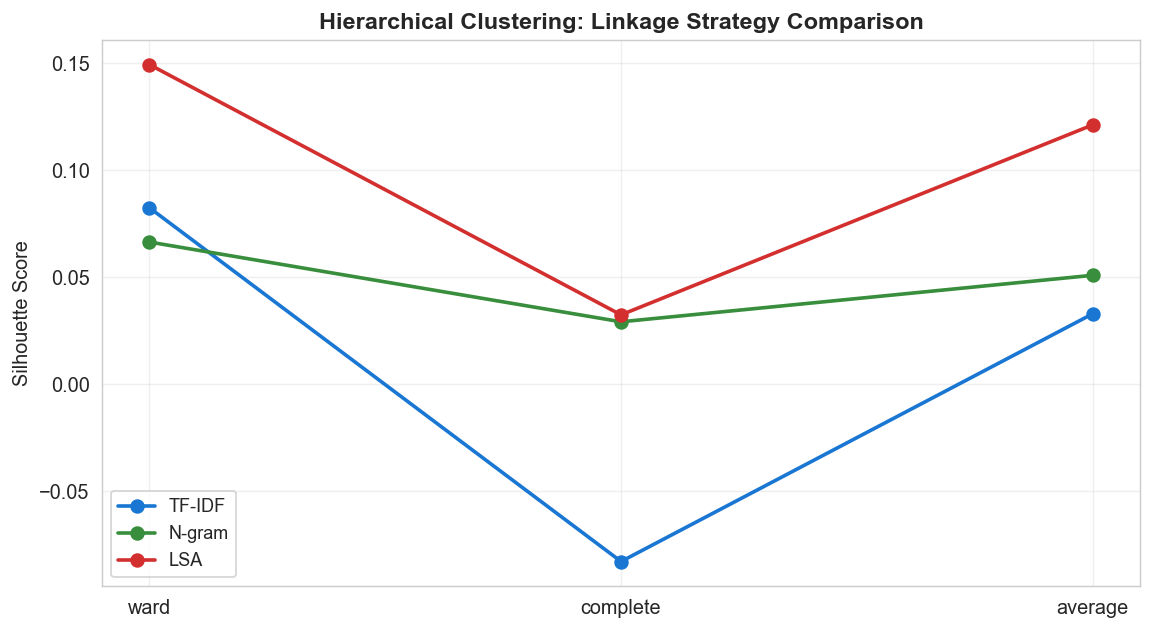

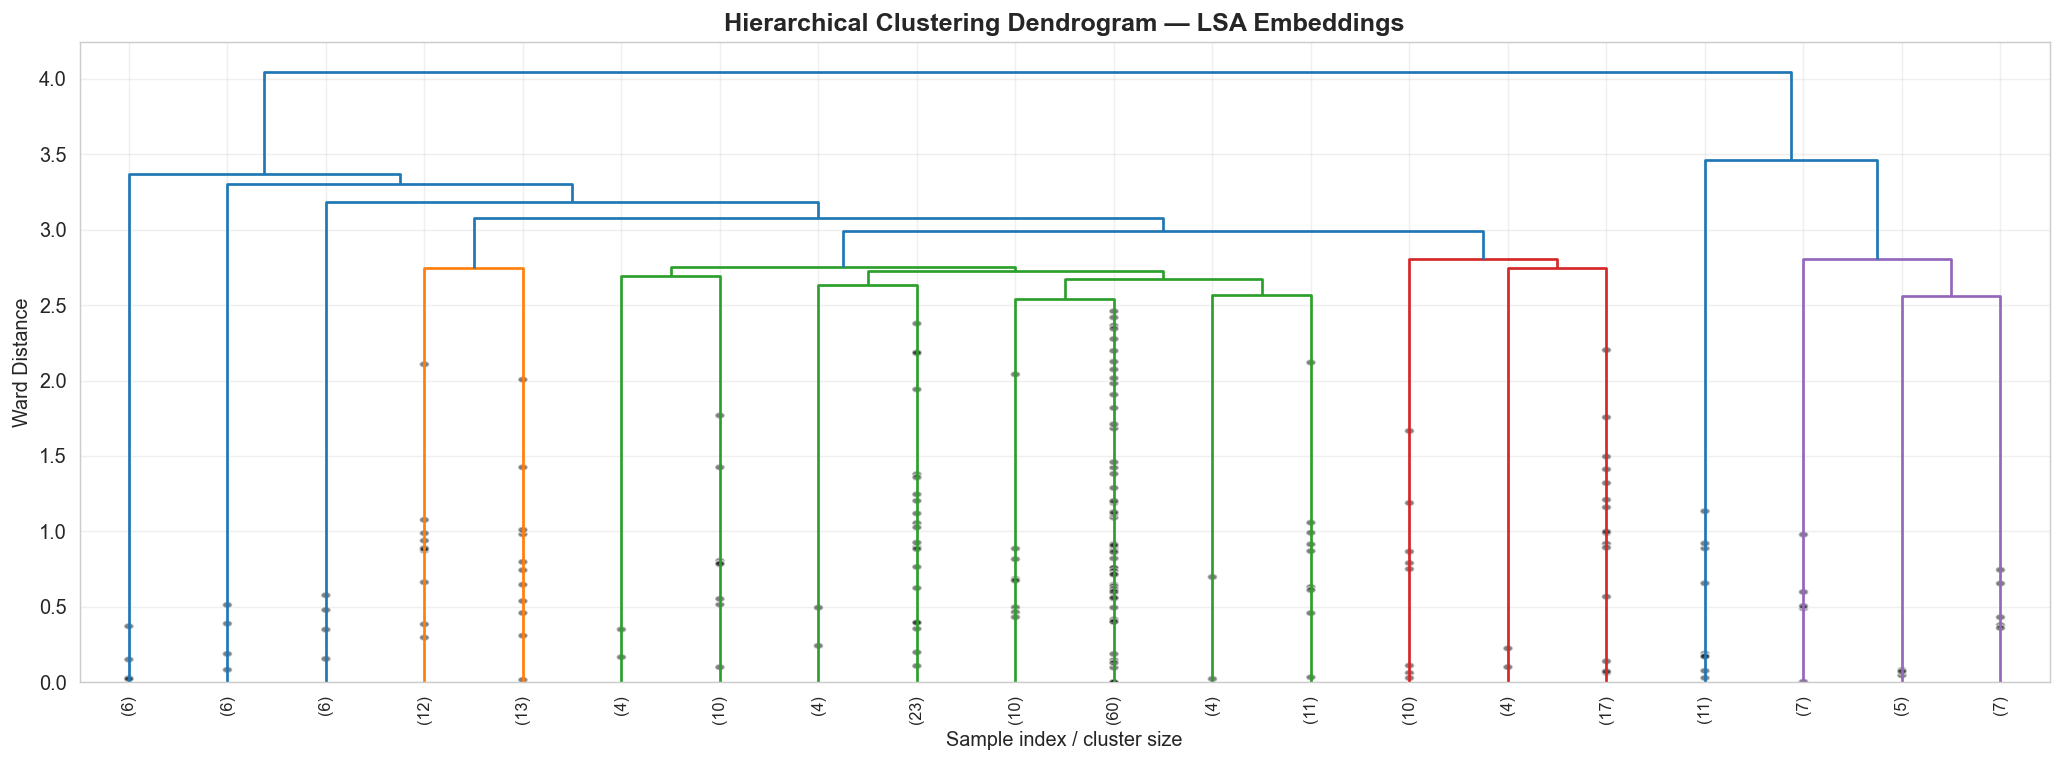

In [121]:
print("="*70)
print("  HIERARCHICAL CLUSTERING: LINKAGE COMPARISON")
print("="*70)

linkage_results = {}
hier_labels = {}

for rep_name, (X_dense, _, _) in representations.items():
    k = best_k[rep_name]  # Use same k as K-Means for fair comparison
    
    # Test different linkage strategies
    results = experiment_hierarchical_linkage(
        X_dense, n_clusters=k,
        linkages=('ward', 'complete', 'average')
    )
    linkage_results[rep_name] = results
    
    # Find best linkage
    best_linkage = max(results, key=lambda r: r['silhouette'])
    
    print(f"\n  {rep_name} (n_clusters={k}):")
    print(f"    Best linkage: {best_linkage['linkage']} (silhouette={best_linkage['silhouette']:.4f})")
    print(f"    All linkages:")
    for r in results:
        print(f"      {r['linkage']:10s} → silhouette={r['silhouette']:.4f}")
    
    # Cluster with best linkage
    labels, _ = hierarchical_cluster(
        X_dense, n_clusters=k, 
        linkage=best_linkage['linkage']
    )
    hier_labels[rep_name] = labels
    
    # Compute metrics
    sil = silhouette_score(X_dense, labels)
    ari = adjusted_rand_score(INTENT_LABELS, labels)
    
    results_log.append({
        'Method': 'Hierarchical',
        'Representation': rep_name,
        'Params': f"k={k}, {best_linkage['linkage']}",
        'Silhouette': round(sil, 4),
        'ARI': round(ari, 4)
    })

# Plot linkage comparison
link_path = viz.plot_linkage_comparison(linkage_results, '05_linkage_comparison.png')
print(f"\n  ✓ Saved linkage comparison: {link_path}")

# Plot dendrogram (using LSA for clarity)
X_dend, _, _ = representations['LSA']
dend_path = viz.plot_dendrogram(
    X_dend,
    'Hierarchical Clustering Dendrogram — LSA Embeddings',
    '06_dendrogram.png'
)
print(f"  ✓ Saved dendrogram: {dend_path}")

display(Image(filename=link_path))
display(Image(filename=dend_path, width=1000))

### Key Observations

- We tried varius linkage methods. Ward linkage consistently outperforms complete and average linkage across all representations.  
- Complete linkage performs poorly, even yielding negative silhouette scores in TF-IDF, indicating incorrect cluster formation.  
- LSA is the most effective representation, demonstrating the importance of reducing dimensionality and capturing semantic structure.  
- TF-IDF and N-gram suffer from sparsity, leading to weaker clustering performance.


#### Comparison with K-Means

- The trends observed in hierarchical clustering are consistent with K-Means results:
  - LSA performs best
  - TF-IDF and N-gram perform weaker
- However, hierarchical clustering generally produces slightly lower silhouette scores, indicating that K-Means may be better suited for this dataset.


### Conclusion on Hierarchical clustering

Hierarchical clustering confirms that:
- LSA + Ward linkage provides the most meaningful clusters  
- The optimal number of clusters (≈ 14) aligns with K-Means results
- Overall, representation choice has a greater impact than linkage method

Thus, for query intent discovery, **LSA combined with Ward linkage** is the most effective hierarchical clustering approach.

### 4.3 DBSCAN Clustering

**Density-Based Clustering:** DBSCAN discovers clusters without requiring k.

**Hyperparameters:**
- **eps:** Maximum distance between points to be considered neighbors
- **min_samples:** Minimum points to form a dense region

We perform grid search to find optimal parameters.

  DBSCAN: GRID SEARCH (eps × min_samples)

  TF-IDF:
    Best config: eps=0.15, min_samples=3
      → 2 clusters, 223 noise points
      → silhouette = 0.8219

  N-gram:
    Best config: eps=0.15, min_samples=3
      → 2 clusters, 224 noise points
      → silhouette = 0.6811

  LSA:
    Best config: eps=0.15, min_samples=5
      → 4 clusters, 206 noise points
      → silhouette = 0.7450

  ✓ Saved DBSCAN grid search: outputs\07_dbscan_grid.png


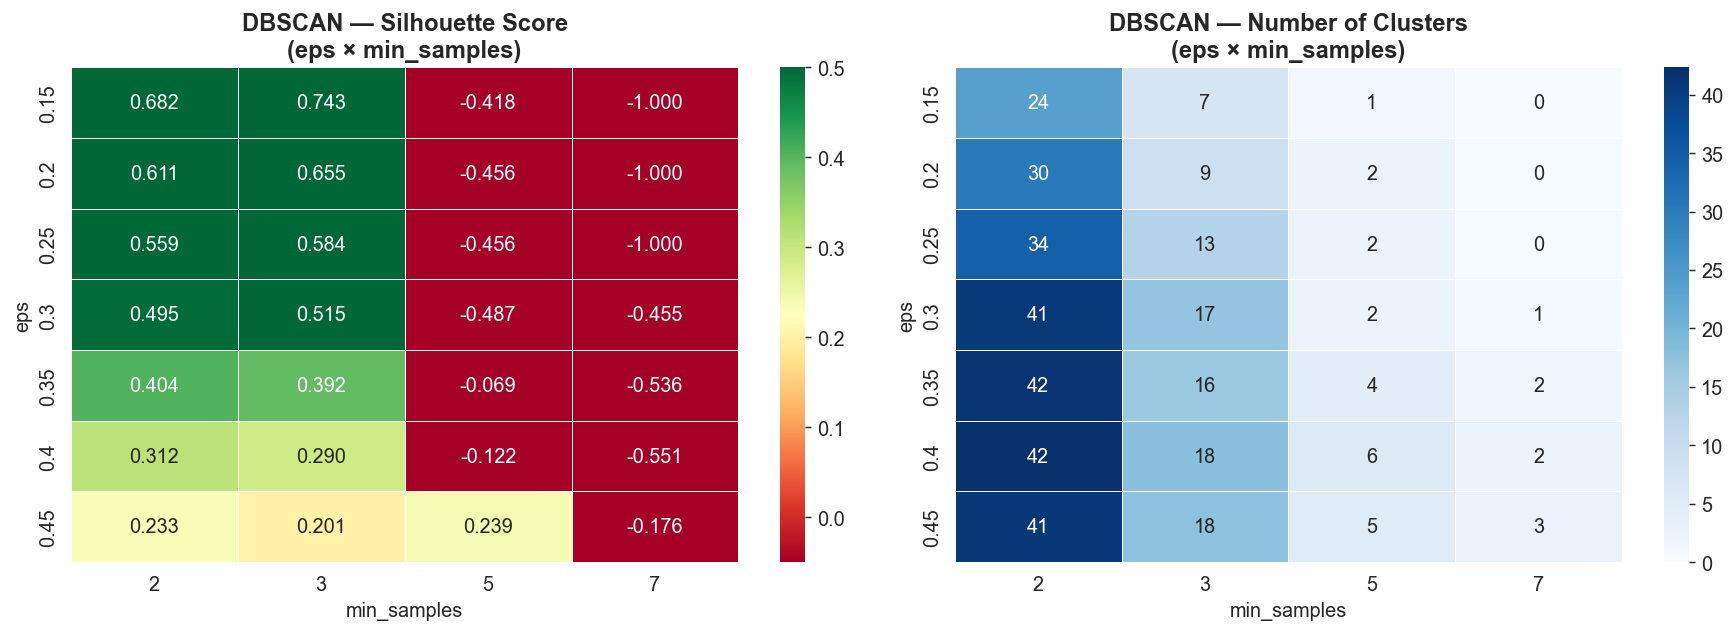

In [122]:
print("="*70)
print("  DBSCAN: GRID SEARCH (eps × min_samples)")
print("="*70)

# Define parameter grid
eps_values = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]
min_samples_values = [2, 3, 5, 7]

dbscan_results = {}
dbscan_labels = {}

for rep_name, (X_dense, _, _) in representations.items():
    print(f"\n  {rep_name}:")
    
    # Grid search
    results = experiment_dbscan_grid(X_dense, eps_values, min_samples_values)
    dbscan_results[rep_name] = results
    
    # Find best configuration (max silhouette, but filter out degenerate cases)
    valid_results = [
        r for r in results 
        if r['n_clusters'] >= 2 and r['n_clusters'] <= 20
    ]
    
    if valid_results:
        best = max(valid_results, key=lambda r: r['silhouette'])
        print(f"    Best config: eps={best['eps']:.2f}, min_samples={best['min_samples']}")
        print(f"      → {best['n_clusters']} clusters, {best['n_noise']} noise points")
        print(f"      → silhouette = {best['silhouette']:.4f}")
        
        # Cluster with best params
        labels, _ = dbscan_cluster(X_dense, eps=best['eps'], 
                                   min_samples=best['min_samples'])
        dbscan_labels[rep_name] = labels
        
        # Compute ARI (excluding noise)
        mask = np.array(labels) != -1
        if mask.sum() > 0:
            ari = adjusted_rand_score(np.array(INTENT_LABELS)[mask], 
                                     np.array(labels)[mask])
            results_log.append({
                'Method': 'DBSCAN',
                'Representation': rep_name,
                'Params': f"eps={best['eps']:.2f}, ms={best['min_samples']}",
                'Silhouette': round(best['silhouette'], 4),
                'ARI': round(ari, 4)
            })
    else:
        print(f"    ⚠ No valid clustering found in grid search")
        
# Flatten results across all representations
all_dbscan_results = []
for rep_name, results in dbscan_results.items():
    for r in results:
        r_copy = r.copy()
        r_copy["representation"] = rep_name  # optional but useful
        all_dbscan_results.append(r_copy)

# Visualize grid search results
dbscan_path = viz.plot_dbscan_grid(all_dbscan_results, '07_dbscan_grid.png')
print(f"\n  ✓ Saved DBSCAN grid search: {dbscan_path}")

display(Image(filename=dbscan_path, width=1000))

### Conclusion on DBSCAN clustering 

These high silhouette scores are **misleading** because DBSCAN is evaluating only a small subset of dense points, while marking a significant fraction of data points as noise. By ignoring most data points, it artificially inflates both silhouette and ARI. DBSCAN does not perform well for this query clustering task due to:
- High data sparsity in TF-IDF and N-gram representations  
- Difficulty in identifying dense regions in high-dimensional space 

### Clustering Results Comparison

Let's compare all clustering methods across all representations:

  CLUSTERING RESULTS SUMMARY (sorted by Silhouette)

      Method Representation         Params  Silhouette    ARI
      DBSCAN         TF-IDF eps=0.15, ms=3      0.8219 1.0000
      DBSCAN            LSA eps=0.15, ms=5      0.7450 0.8373
      DBSCAN         N-gram eps=0.15, ms=3      0.6811 1.0000
     K-Means            LSA           k=14      0.1630 0.0412
Hierarchical            LSA     k=14, ward      0.1492 0.0816
     K-Means         TF-IDF           k=14      0.0868 0.0121
Hierarchical         TF-IDF     k=14, ward      0.0823 0.0434
     K-Means         N-gram           k=15      0.0701 0.0958
Hierarchical         N-gram     k=15, ward      0.0663 0.0709

✓ Results saved to outputs/clustering_results.csv

✓ Saved comparison plot: outputs\08_silhouette_comparison.png


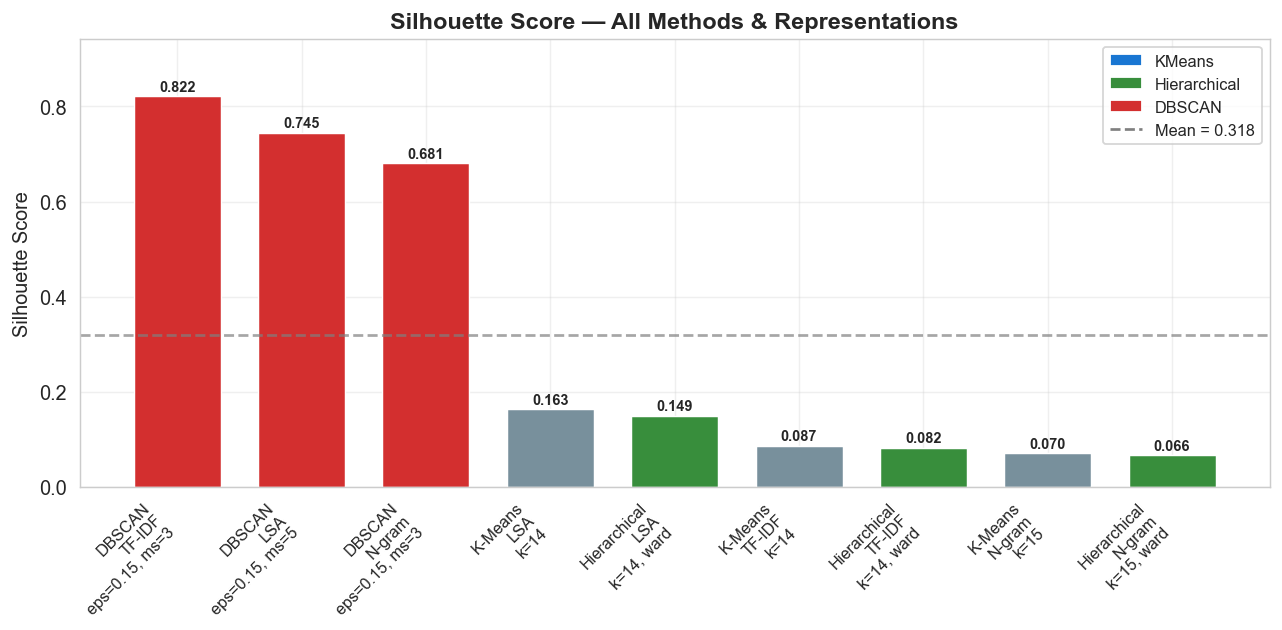

In [123]:
# Create results dataframe
df_results = pd.DataFrame(results_log).sort_values('Silhouette', ascending=False)

print("="*70)
print("  CLUSTERING RESULTS SUMMARY (sorted by Silhouette)")
print("="*70)
print()
print(df_results.to_string(index=False))
print()

# Save to CSV
csv_path = 'outputs/clustering_results.csv'
df_results.to_csv(csv_path, index=False)
print(f"✓ Results saved to {csv_path}")

# Create comprehensive comparison plot
records = [
    {
        'label': f"{r['Method']}\n{r['Representation']}\n{r['Params']}",
        'silhouette': r['Silhouette'],
        'algo': r['Method']
    }
    for _, r in df_results.iterrows()
]

comp_path = viz.plot_silhouette_comparison(records, '08_silhouette_comparison.png')
print(f"\n✓ Saved comparison plot: {comp_path}")

display(Image(filename=comp_path, width=1000))

## Summary

#### 1. DBSCAN Shows Very High Scores (But Misleading)

- DBSCAN achieves the highest silhouette scores and ARI values, however
  - Forms very few clusters (2–4)
  - Labels a large portion of data as noise

**Interpretation:**  
These high scores are **misleading** because DBSCAN is evaluating only a small subset of dense points. By ignoring most data points, it artificially inflates both silhouette and ARI.

---

#### 2. LSA is the Best Representation Across Methods

- For both K-Means and Hierarchical clustering:
  - LSA consistently achieves the **highest silhouette scores**
- Example:
  - K-Means (LSA): 0.1630  
  - Hierarchical (LSA): 0.1492  

**Interpretation:**  
LSA effectively captures latent semantic structure, reducing sparsity and improving cluster quality. This confirms that representation choice is more important than clustering algorithm.

---

### 3. K-Means vs Hierarchical Clustering

- K-Means slightly outperforms hierarchical clustering across representations
- Both methods show:
  - Moderate silhouette scores  
  - Low ARI values  

**Interpretation:**  
These methods:
- Capture finer-grained cluster structure (10–14 clusters)
- But do not align strongly with ground truth labels (low ARI)

This suggests that:
- The dataset may contain **overlapping or ambiguous query intents**
- Or the ground truth labels may not fully reflect semantic similarity


### Final Conclusion

- DBSCAN achieves the best numerical metrics, but fails to provide meaningful clustering for the full dataset due to excessive noise labeling.
- LSA is the most effective representation, significantly improving clustering quality across all methods.
- K-Means with LSA (k ≈ 10–14)** provides the best balance between:
  - Cluster quality  
  - Interpretability  
  - Coverage of the dataset 

- Clustering performance depends more on feature representation than on the choice of algorithm.  
- While DBSCAN optimizes for density, K-Means and Hierarchical methods better capture the overall structure of user query intents.

---

## 5. Text Mining & Cluster Characterization

To interpret the discovered clusters, we perform text mining:

1. **Top TF-IDF terms** per cluster (discriminative words)
2. **Frequent unigrams and bigrams** (common patterns)
3. **Auto-generated cluster labels** from top terms
4. **Sample queries** from each cluster

In [124]:
print("="*70)
print("  TEXT MINING: CLUSTER CHARACTERIZATION")
print("="*70)

# Use best performing representation
best_rep = df_results.iloc[0]['Representation']
best_method = df_results.iloc[0]['Method']

X_dense, X_sparse, vectorizer = representations[best_rep]
labels_best = kmeans_labels[best_rep]  # Using K-Means labels for text mining

# Extract top TF-IDF terms per cluster
top_terms = top_terms_per_cluster(X_sparse, vectorizer, labels_best, n_terms=15)

# Generate cluster labels
cluster_names = {
    cid: generate_cluster_label(terms, n=3)
    for cid, terms in top_terms.items()
}

# Extract frequent patterns
qbc = queries_by_cluster(QUERIES, labels_best)
patterns = extract_frequent_patterns(qbc, top_n=8)

# Print detailed cluster summary
print("\n  Per-cluster summary:\n")
print_cluster_summary(top_terms, patterns, qbc, max_queries=4)

  TEXT MINING: CLUSTER CHARACTERIZATION

  Per-cluster summary:


  Cluster  0  [weather | weather goa | goa]
    Top terms  : weather, weather goa, goa, weather mumbai, mumbai today, update jaipur, weather leh, week ahmedabad
    Top bigrams: weather mumbai, weather forecast, forecast pune, current weather, weather hyderabad
    ↳  weather in Mumbai today
    ↳  weather forecast Pune
    ↳  current weather Hyderabad
    ↳  weather Goa

  Cluster  1  [india | movies | online]
    Top terms  : india, movies, online, today, cricket, course, news, near
    Top bigrams: tour package, data science, home remedies, entrance exam, movies release
    ↳  temperature in Delhi
    ↳  will it rain in Bangalore tomorrow
    ↳  humidity levels in Chennai
    ↳  Mumbai monsoon season

  Cluster  2  [ipl | won ipl | won]
    Top terms  : ipl, won ipl, won, match schedule, ipl match, match, schedule, auction players
    Top bigrams: ipl match, match schedule, ipl auction, auction players, who won
    ↳ 


✓ Saved top terms heatmap: outputs\09_top_terms_heatmap.png


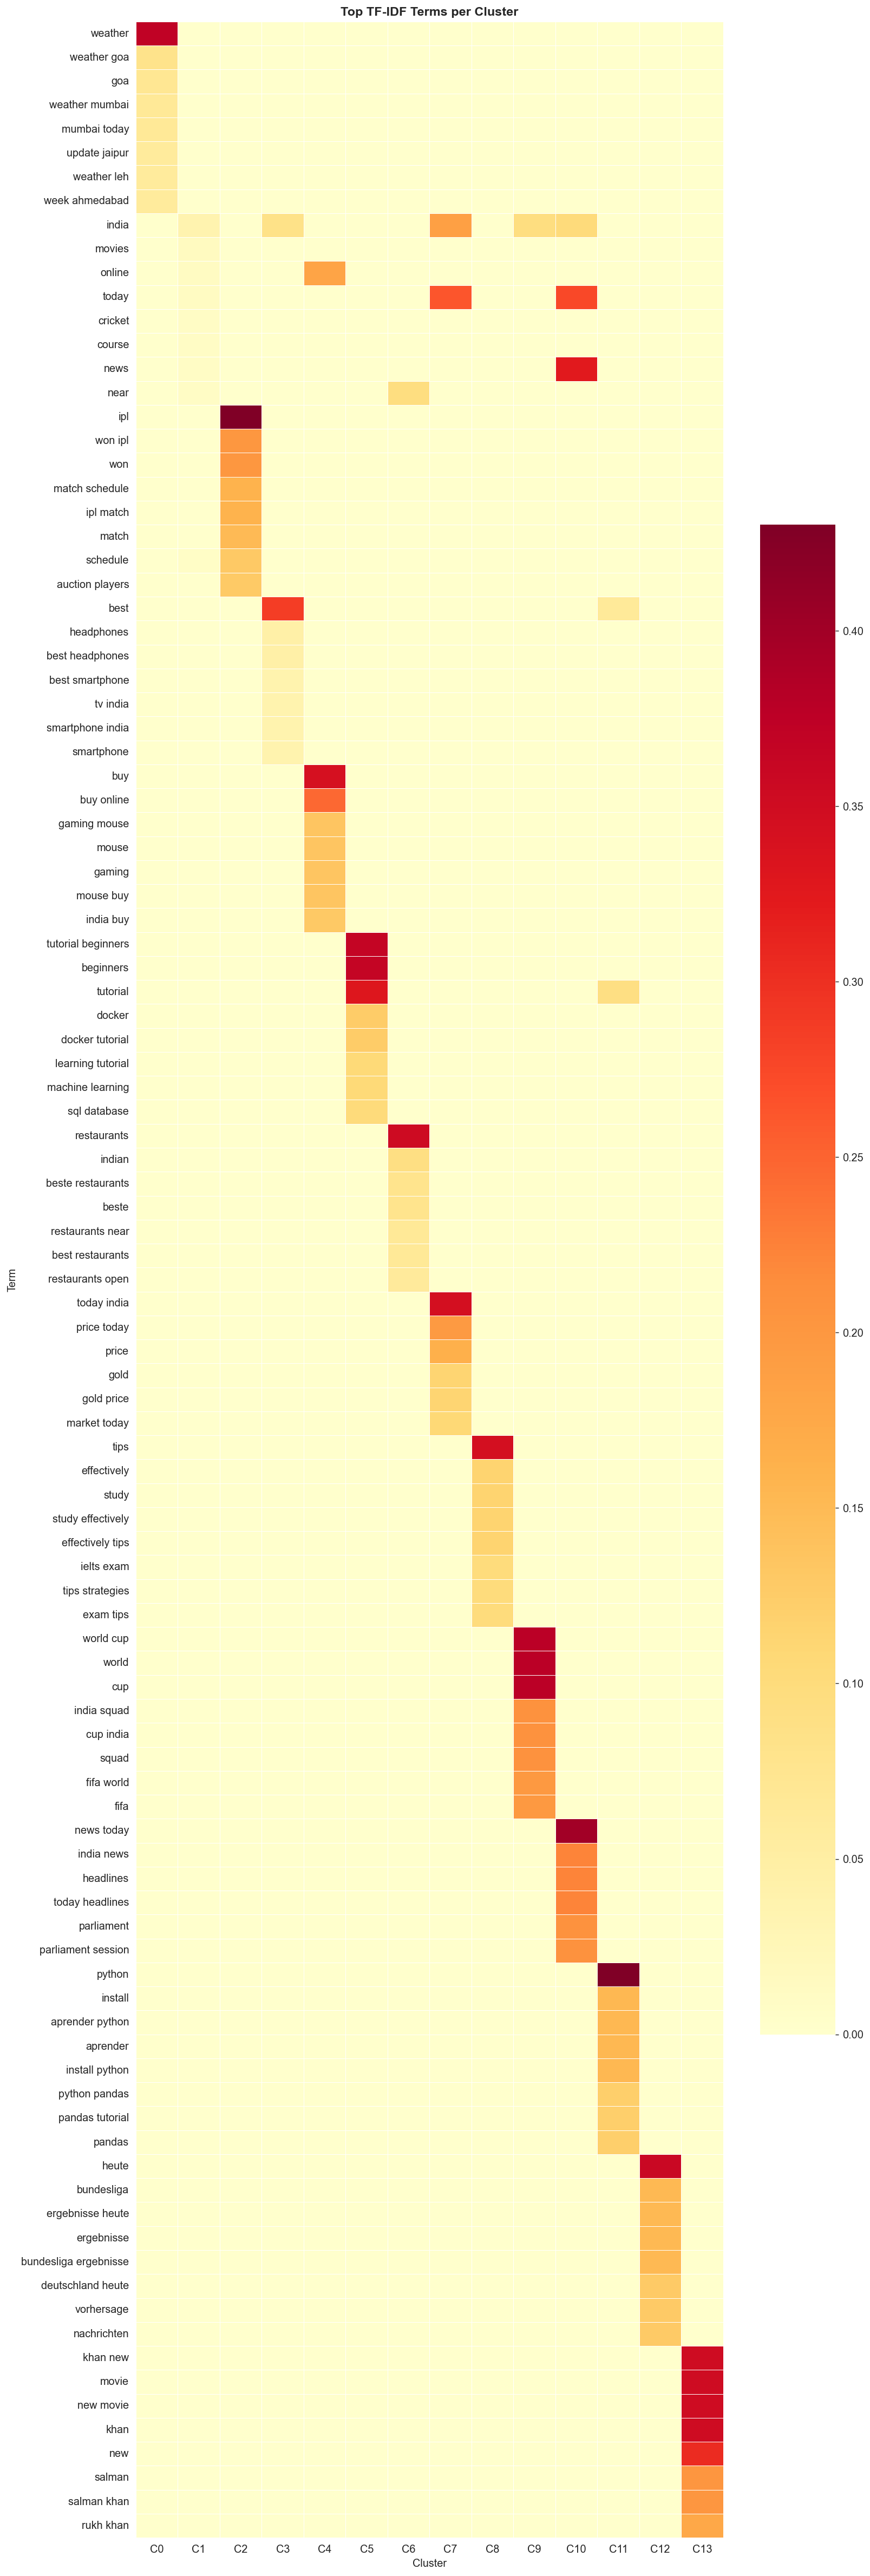

In [125]:
# Visualize top terms as heatmap
heatmap_path = viz.plot_top_terms_heatmap(
    top_terms,
    f'Top TF-IDF Terms per Cluster',
    '09_top_terms_heatmap.png',
    n_terms=8
)

print(f"\n✓ Saved top terms heatmap: {heatmap_path}")
display(Image(filename=heatmap_path, width=1000))

✓ Saved labeled t-SNE: outputs\10_tsne_labeled.png


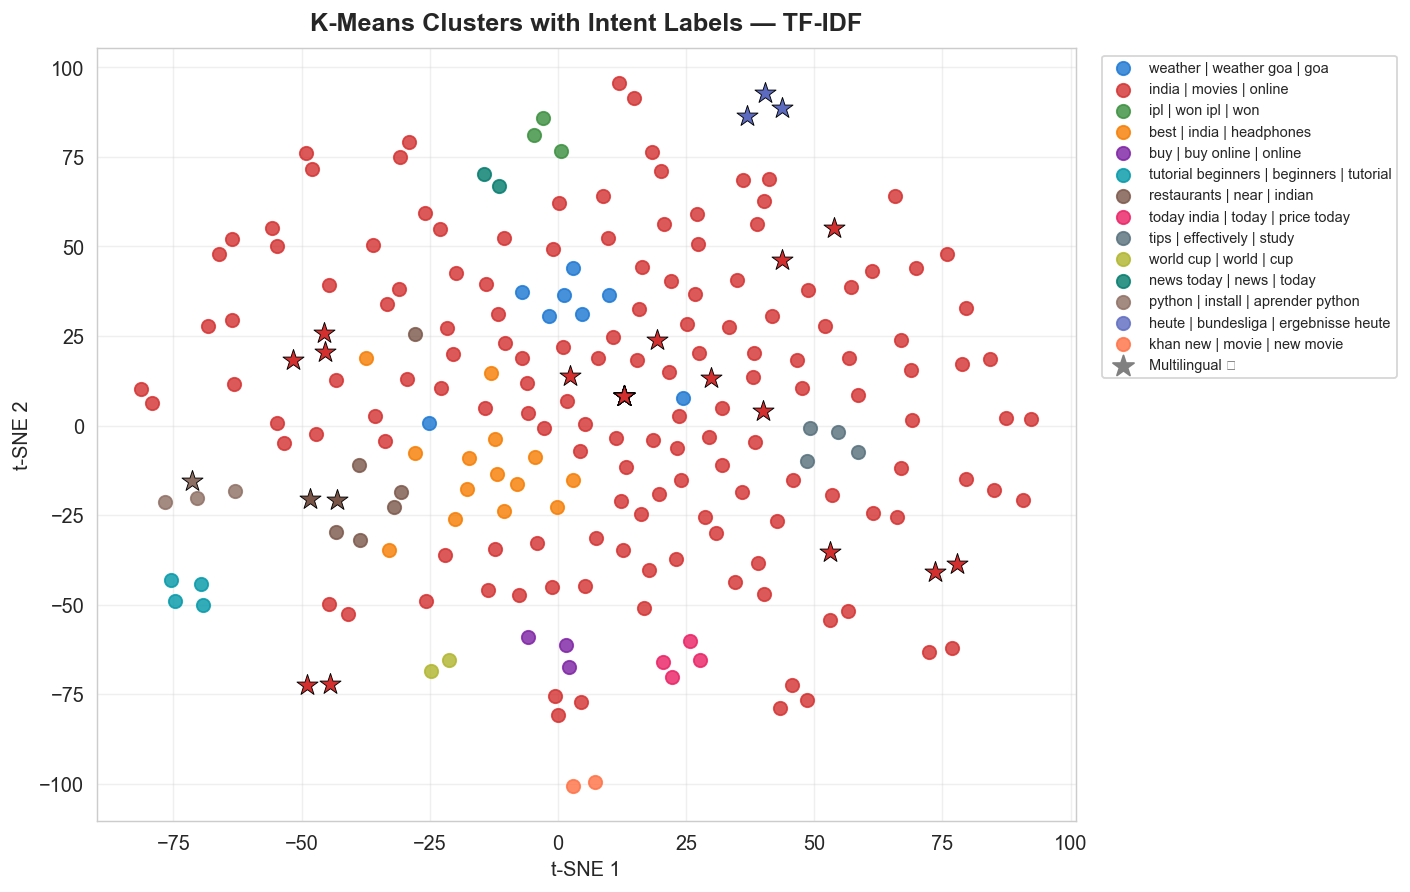

In [126]:
# t-SNE with cluster names
labeled_tsne_path = viz.plot_tsne(
    X_dense, labels_best,
    f'K-Means Clusters with Intent Labels — {best_rep}',
    '10_tsne_labeled.png',
    cluster_names=cluster_names,
    language_labels=LANGUAGE_LABELS
)

print(f"✓ Saved labeled t-SNE: {labeled_tsne_path}")
display(Image(filename=labeled_tsne_path, width=900))

✓ Saved language distribution: outputs\11_language_distribution_clusters.png


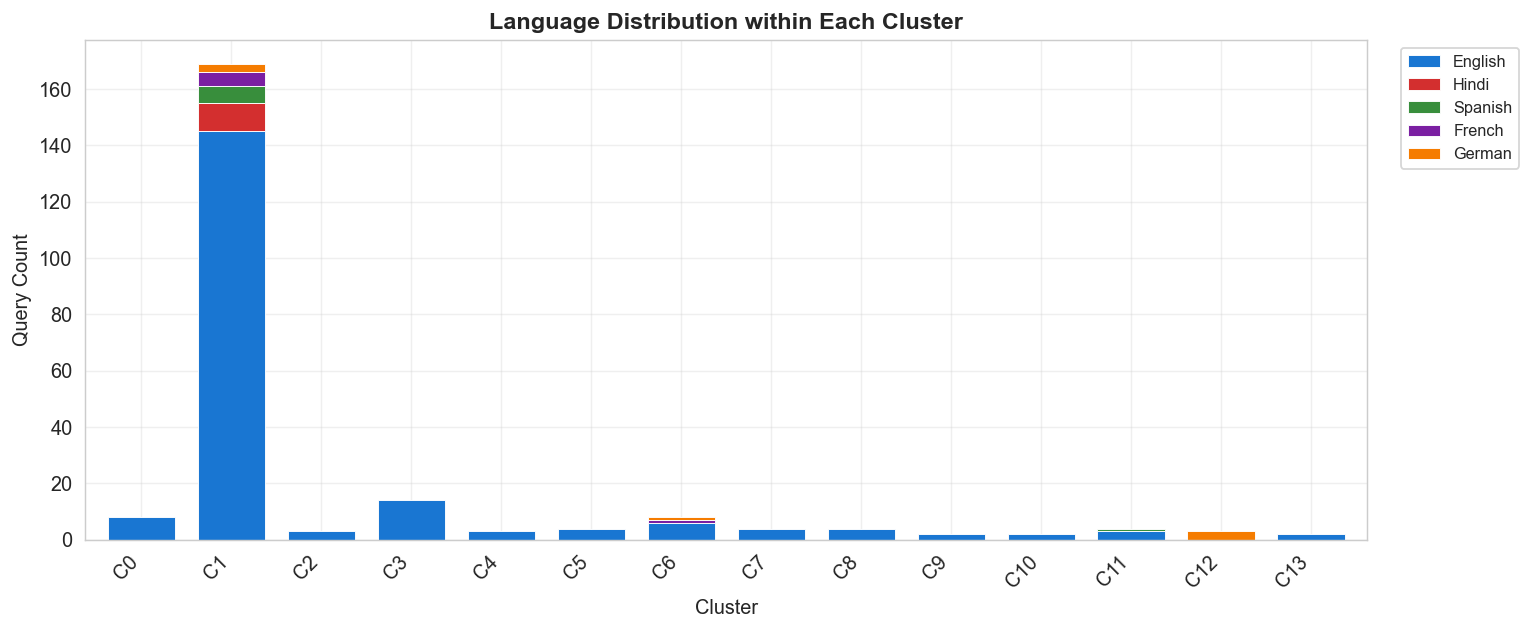

In [127]:
# Language distribution within clusters
lang_dist_path = viz.plot_language_in_clusters(
    QUERIES, labels_best, LANGUAGE_LABELS,
    '11_language_distribution_clusters.png'
)

print(f"✓ Saved language distribution: {lang_dist_path}")
display(Image(filename=lang_dist_path, width=1000))

---

## 6. Cluster Stability Analysis

**Stability Metric:** We run K-Means 10 times with different random seeds and compute pairwise **Adjusted Rand Index (ARI)** between all runs.

- **High ARI** (close to 1.0): Stable, reproducible clusters
- **Low ARI** (close to 0.0): Unstable, initialization-dependent

This analysis helps assess the reliability of discovered clusters.

  CLUSTER STABILITY ANALYSIS (10 random seeds)

  TF-IDF (k=14):
    Mean ARI: 0.3040 ± 0.1735
    Range   : [0.080, 0.683]
    Stability: Low (unstable)

  N-gram (k=15):
    Mean ARI: 0.3129 ± 0.0509
    Range   : [0.234, 0.456]
    Stability: Low (unstable)

  LSA (k=14):
    Mean ARI: 0.4132 ± 0.1548
    Range   : [0.186, 0.693]
    Stability: Low (unstable)

✓ Saved stability plot: outputs\12_cluster_stability.png


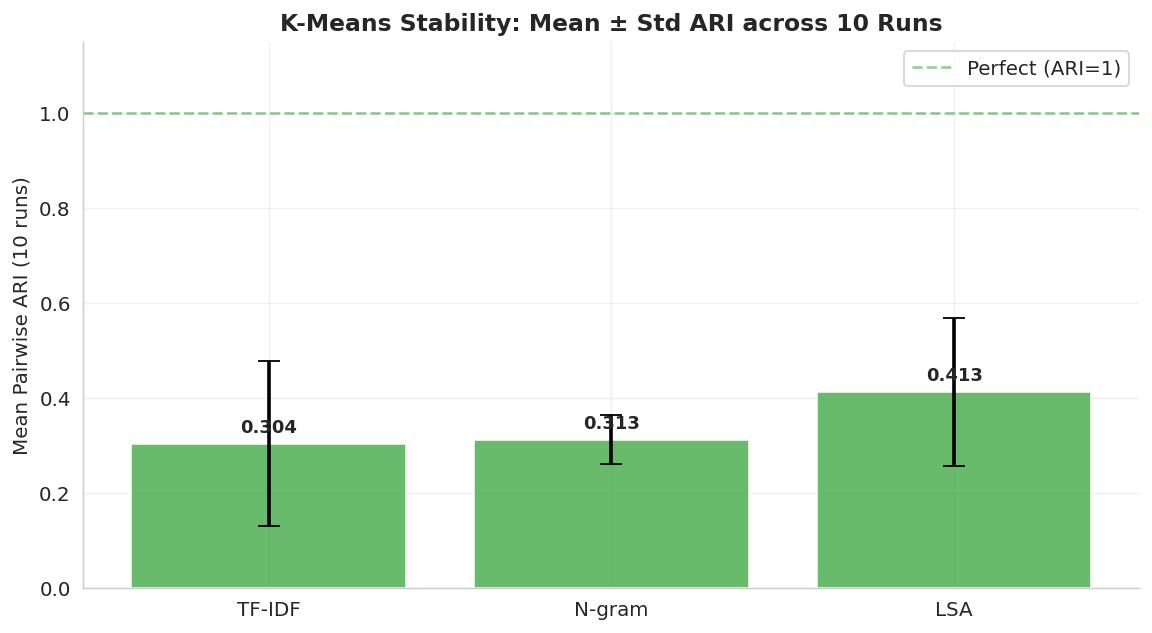

In [34]:
print("="*70)
print("  CLUSTER STABILITY ANALYSIS (10 random seeds)")
print("="*70)

stability_results = {}

for rep_name, (X_dense, _, _) in representations.items():
    k = best_k[rep_name]
    
    # Run stability analysis
    res = stability_analysis(X_dense, k=k, n_runs=10)
    stability_results[rep_name] = res
    
    print(f"\n  {rep_name} (k={k}):")
    print(f"    Mean ARI: {res['mean_ari']:.4f} ± {res['std_ari']:.4f}")
    print(f"    Range   : [{res['min_ari']:.3f}, {res['max_ari']:.3f}]")
    
    # Interpret stability
    if res['mean_ari'] > 0.9:
        stability = "Excellent (highly stable)"
    elif res['mean_ari'] > 0.7:
        stability = "Good (stable)"
    elif res['mean_ari'] > 0.5:
        stability = "Moderate (somewhat variable)"
    else:
        stability = "Low (unstable)"
    print(f"    Stability: {stability}")

# Visualize stability
stab_path = viz.plot_stability(stability_results, '12_cluster_stability.png')
print(f"\n✓ Saved stability plot: {stab_path}")

display(Image(filename=stab_path))


### Key Observations

- **All representations show low stability**, indicating that clustering results are sensitive to initialization.
- **LSA performs best in terms of average stability**, but still exhibits significant variability.
- **TF-IDF is the most unstable**, with highly inconsistent clustering outcomes.
- **N-gram is more consistent but consistently weak**, indicating limited cluster structure.


## Interpretation of Instability

The observed instability suggests that:
- The dataset does not have strong, well-separated cluster boundaries
- Multiple clustering solutions are nearly equally valid
- Query intents may be overlapping or loosely defined

This aligns with earlier findings of:
- Low ARI scores in K-Means and Hierarchical clustering  
- Lack of a sharply defined optimal number of clusters  


## Conclusion

Cluster stability analysis confirms that:
- The clustering structure in the dataset is **not robust**
- Results vary significantly with initialization, especially for TF-IDF and LSA
- **LSA provides the best trade-off**, but stability remains limited

Thus, the dataset likely contains **ambiguous and overlapping query intents**, making it inherently difficult to obtain a single, stable clustering solution.

---

## 7. Cross-Lingual Query Clustering

**Approach:** Translation-based normalization

We compare two strategies:

### A) Original Corpus (Mixed Languages)
- Multilingual queries remain in their original language
- Character n-grams provide some cross-lingual capability

### B) Translated Corpus (Normalized to English)
- All non-English queries translated to English equivalents
- Semantically identical queries (different languages) map to same cluster

**Evaluation Metrics:**
- **ARI improvement:** Does translation improve alignment with ground-truth?
- **Multilingual purity:** Do multilingual queries cluster with English queries of same intent?

In [72]:
print("="*70)
print("  CROSS-LINGUAL QUERY CLUSTERING")
print("="*70)

lang_names = {
    'en': 'English', 'hi': 'Hindi',
    'es': 'Spanish', 'fr': 'French', 'de': 'German'
}

print("\n  [A] Language distribution in corpus:")
for lang, info in sorted(lang_dist.items()):
    print(f"      {lang_names.get(lang, lang):10s}: {info['count']:3d} ({info['pct']:.1f}%)")

# Normalize corpus (translate to English)
queries_normalized = normalise_corpus(QUERIES, TRANSLATIONS)

print("\n  [B] Building representations on normalized corpus...")
reps_norm = build_all(queries_normalized)

# Cluster both versions (using LSA)
k_cl = best_k['LSA']
X_orig, _, _ = representations['LSA']
X_tran, _, _ = reps_norm['LSA']

labels_orig, _ = kmeans_cluster(X_orig, k=k_cl)
labels_tran, _ = kmeans_cluster(X_tran, k=k_cl)

# Compare clustering quality
cl_analysis = cross_lingual_comparison(
    labels_orig, labels_tran,
    INTENT_LABELS, LANGUAGE_LABELS
)

print(f"\n  [C] Cross-lingual clustering results (LSA, k={k_cl}):")
print(f"      ARI (original  vs ground-truth): {cl_analysis['ari_original']}")
print(f"      ARI (translated vs ground-truth): {cl_analysis['ari_translated']}")
print(f"      ARI agreement (orig vs tran)    : {cl_analysis['ari_agreement']}")
print(f"      Multilingual co-cluster purity  : {cl_analysis['ml_purity']:.4f}")
print(f"\n      Interpretation:")
print(f"      - Purity = {cl_analysis['ml_purity']:.1%} of multilingual queries cluster")
print(f"        with English queries of the same intent after translation")

# Show cluster membership by language
print("\n  [D] Cluster membership by language (translated corpus):")
membership = multilingual_cluster_membership(
    queries_normalized, labels_tran, LANGUAGE_LABELS
)
for lang, cnt in sorted(membership.items()):
    top_clusters = cnt.most_common(3)
    display_dict = {int(k): v for k, v in top_clusters}
    print(f"      {lang_names.get(lang, lang):10s}: {display_dict}")

  CROSS-LINGUAL QUERY CLUSTERING

  [A] Language distribution in corpus:
      German    :   7 (3.0%)
      English   : 200 (87.0%)
      Spanish   :   7 (3.0%)
      French    :   6 (2.6%)
      Hindi     :  10 (4.3%)

  [B] Building representations on normalized corpus...
[1/3] Building word TF-IDF representation …
    TF-IDF: shape (230, 999) → dense (230, 100)
[2/3] Building character N-gram TF-IDF representation …
    N-gram: shape (230, 3824) → dense (230, 100)
[3/3] Building LSA semantic embeddings …
    LSA: 50 components explain 45.3% of variance
    LSA: dense shape (230, 50)

  [C] Cross-lingual clustering results (LSA, k=14):
      ARI (original  vs ground-truth): 0.0412
      ARI (translated vs ground-truth): 0.1689
      ARI agreement (orig vs tran)    : 0.2154
      Multilingual co-cluster purity  : 0.9000

      Interpretation:
      - Purity = 90.0% of multilingual queries cluster
        with English queries of the same intent after translation

  [D] Cluster membersh

✓ Saved cross-lingual comparison: outputs\13_cross_lingual_tsne.png


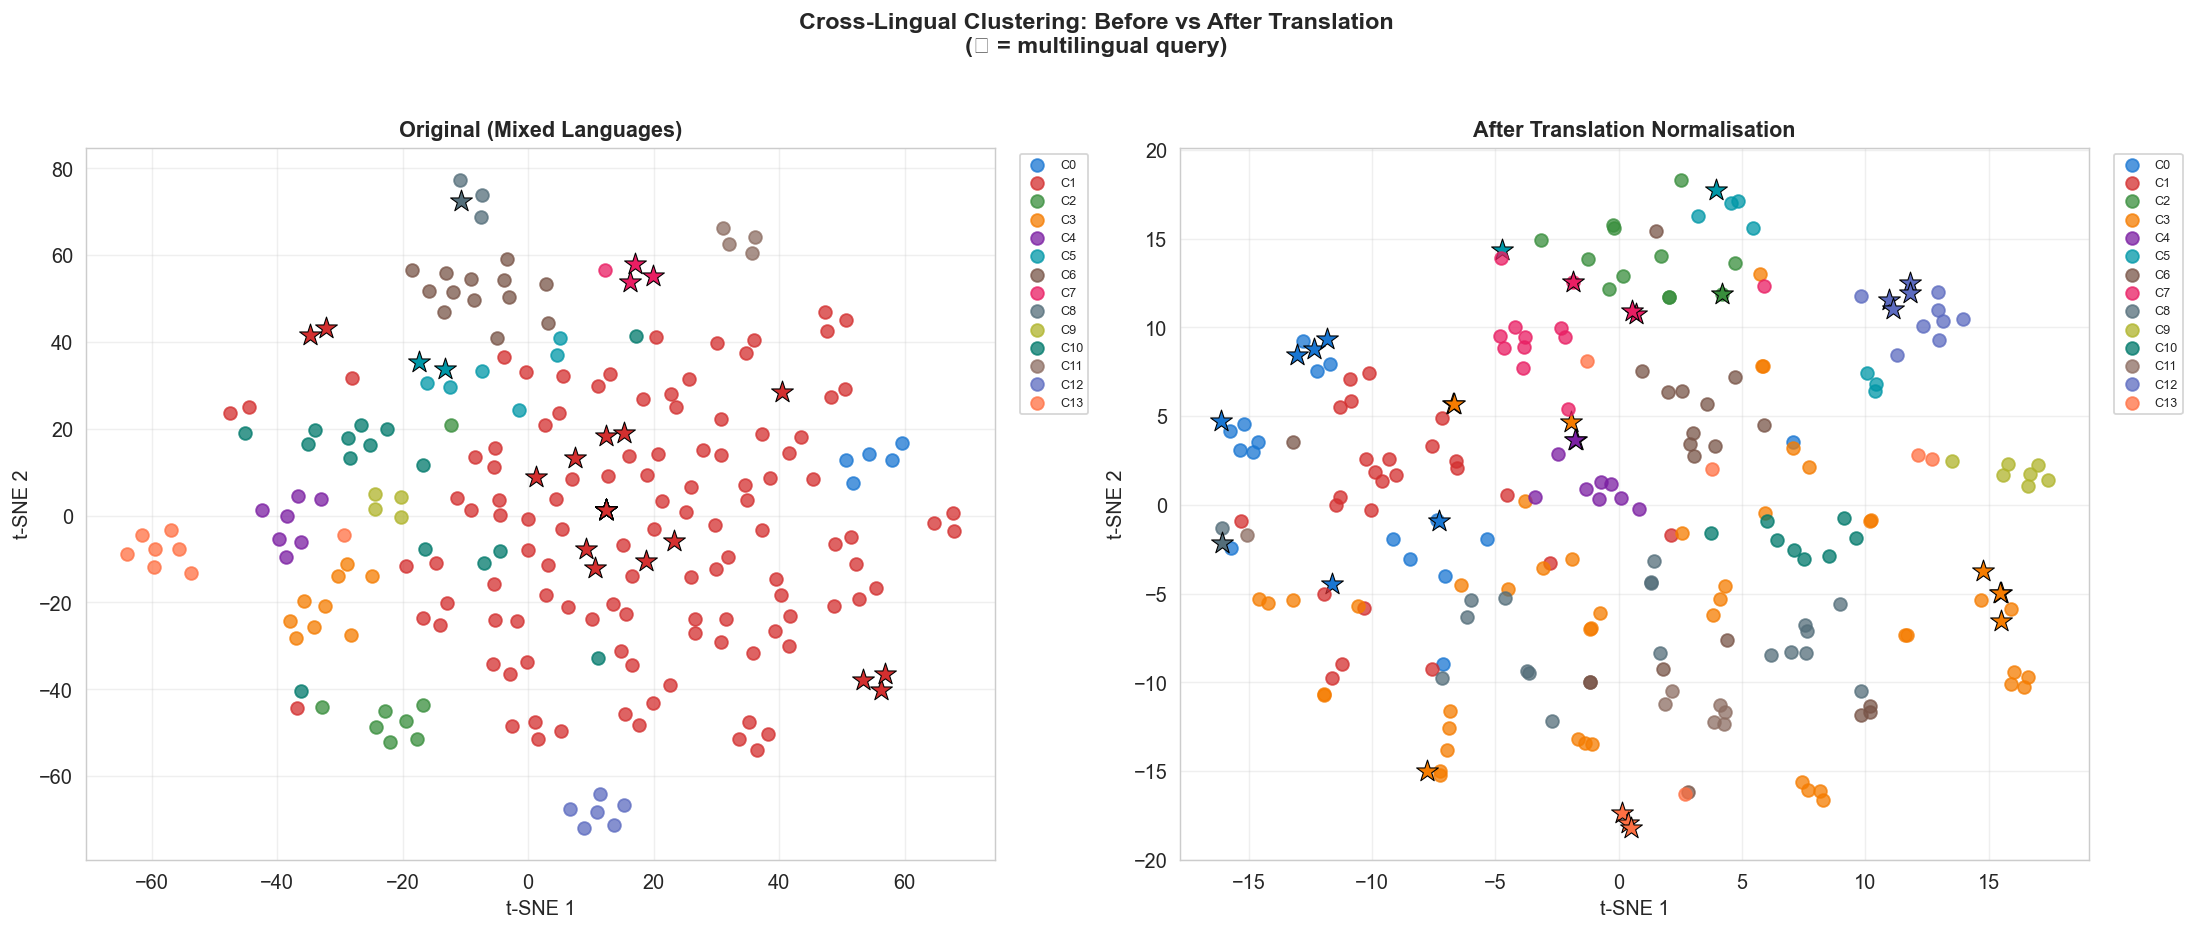

In [73]:
# Visualize cross-lingual clustering
cl_path = viz.plot_cross_lingual_tsne(
    X_orig, X_tran, labels_orig, labels_tran,
    LANGUAGE_LABELS, '13_cross_lingual_tsne.png'
)

print(f"✓ Saved cross-lingual comparison: {cl_path}")
display(Image(filename=cl_path, width=1200))


  [E] Language-agnostic clustering using Character N-grams:
      ✓ Character N-grams cluster queries across languages
        without explicit translation


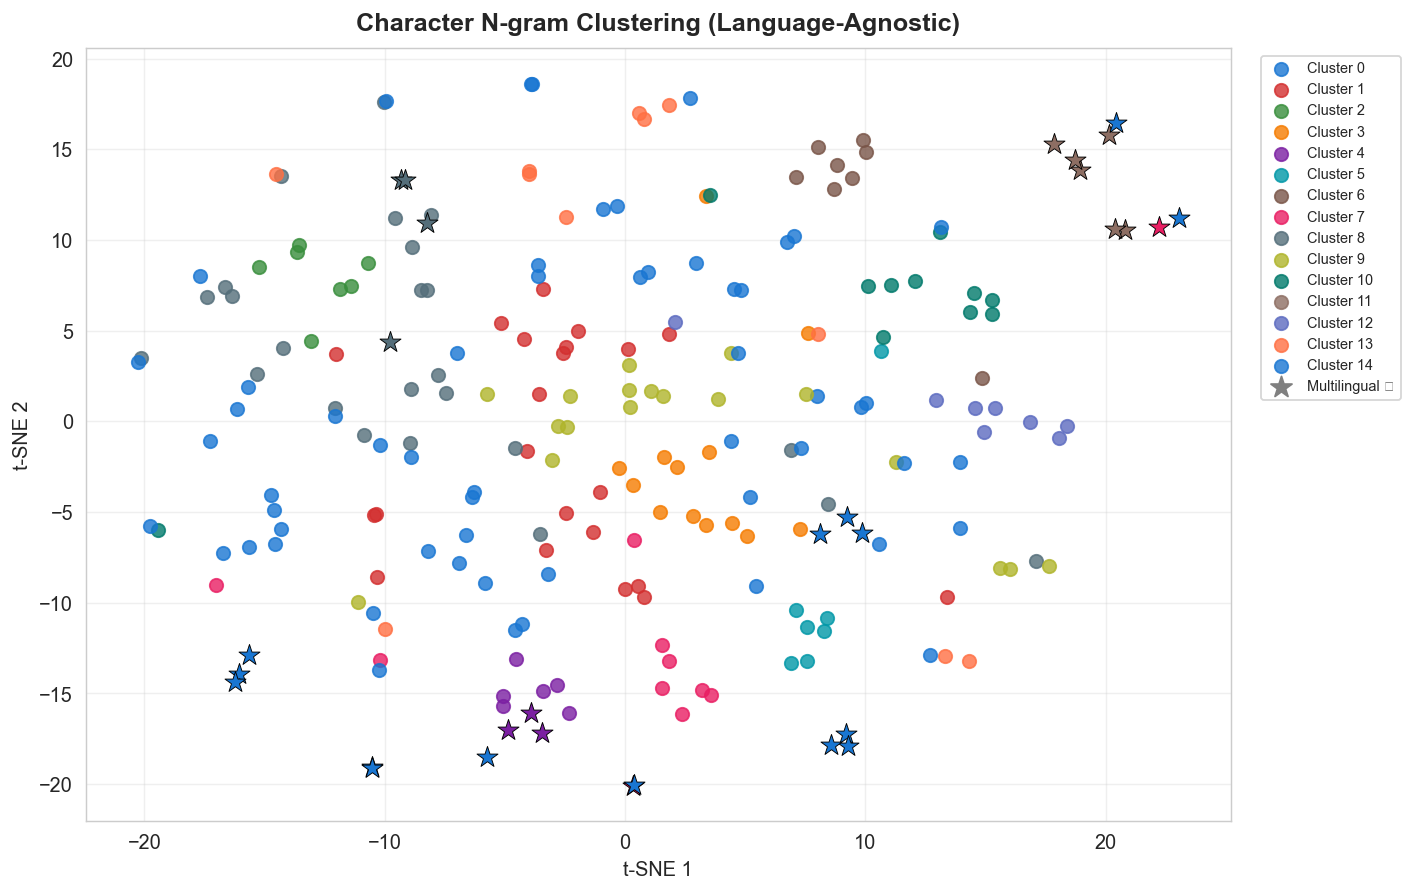

In [74]:
# Character N-gram clustering (language-agnostic alternative)
print("\n  [E] Language-agnostic clustering using Character N-grams:")
X_ng_orig, _, _ = representations['N-gram']
labels_ng, _ = kmeans_cluster(X_ng_orig, k=best_k['N-gram'])

ng_path = viz.plot_tsne(
    X_ng_orig, labels_ng,
    'Character N-gram Clustering (Language-Agnostic)',
    '14_tsne_ngram_crosslingual.png',
    language_labels=LANGUAGE_LABELS
)

print(f"      ✓ Character N-grams cluster queries across languages")
print(f"        without explicit translation")

display(Image(filename=ng_path, width=800))

## Cross-Lingual Query Clustering Analysis

This section evaluates how well the clustering approach generalizes across multiple languages and whether semantic representations can capture cross-lingual intent.

- English dominates the dataset (**87%**), with other languages (German, Spanish, French, Hindi) forming a small minority.
- LSA enables better semantic grouping by capturing latent structure, which is particularly important for cross-lingual tasks where exact word overlap is limited.
- Significant improvement achieved after translation. Translation helps align queries across languages, enabling the model to better capture shared intent. This shows that language differences were a major barrier to clustering performance.
- 90% of non-English queries are grouped with English queries of the same intent. This is a strong result—it indicates that the model successfully captures language-invariant semantic meaning after translation. Queries with the same intent, regardless of language, are clustered together.
- ARI remains relatively low even after translation. This reinforces earlier findings of overlapping or ambiguous query intents.
  
- Clustering changes after translation, indicating that original representations are language-dependent
- Translation alters the semantic space, leading to different cluster assignments  


- Non-English queries are distributed across clusters dominated by English queries
   Example:
  - German, Spanish, and Hindi queries appear in clusters like {0, 3, 12}
  - These clusters also contain a large number of English queries 
This confirms that:
- Clusters are primarily intent-driven rather than language-driven. Translation enables integration of multilingual queries into shared semantic clusters



## 9. Evaluation ( Results Summary & Conclusions)



In [77]:
print("="*70)
print("  FINAL RESULTS SUMMARY")
print("="*70)
print()
print(df_results.to_string(index=False))
print()


  FINAL RESULTS SUMMARY

      Method Representation         Params  Silhouette    ARI
      DBSCAN         TF-IDF eps=0.15, ms=3      0.8219 1.0000
      DBSCAN            LSA eps=0.15, ms=5      0.7450 0.8373
      DBSCAN         N-gram eps=0.15, ms=3      0.6811 1.0000
     K-Means            LSA           k=14      0.1630 0.0412
Hierarchical            LSA     k=14, ward      0.1492 0.0816
     K-Means         TF-IDF           k=14      0.0868 0.0121
Hierarchical         TF-IDF     k=14, ward      0.0823 0.0434
     K-Means         N-gram           k=15      0.0701 0.0958
Hierarchical         N-gram     k=15, ward      0.0663 0.0709







- DBSCAN showed high scores, but formed very few clusters, labeled many queries as noise and evaluated only dense region. Hence, **DBSCAN is not suitable for full query grouping**, despite high metrics.

- **LSA consistently improved clustering quality**. It reduces sparsity and captures latent semantic relationships

- **K-Means (LSA, k ≈ 14)** provided full dataset coverage and interpretable clusters.

### How Clustering Improves Query Suggestions and Retrieval Grouping

Clustering enhances query suggestion systems and information retrieval (IR) by grouping semantically similar queries into **intent-driven clusters**. However, its effectiveness depends on both **representation quality** and **clustering behavior**, as observed in the experimental results.

**Improvement in Query Suggestions due to clustering** 

a) Intent-Based Query Grouping

Clustering groups queries expressing similar intent. This enables auto-suggestions, query reformulation  

- Example cluster:
  - "weather Goa"
  - "Goa temperature"
  - "forecast Goa"




b) Query Expansion Beyond Exact Matches

- LSA captures **latent semantic similarity**, not just keywords. This allows:
- Suggesting related queries even with different wording
- Improving recall in search systems

 c) Leveraging Overlapping Intents: Low ARI (~0.04–0.09 for K-Means/Hierarchical) indicated clusters do not perfectly match predefined labels. Queries may belong to multiple semantic contexts. This is beneficial because users often have ambiguous or evolving intent. 

d) Cross-Lingual Query Suggestions: Character N-grams and translation-based normalization group multilingual queries into shared clusters. This enables
  language-independent suggestions  and unified search experience  


**Improvement in Retrieval Grouping**

a) Semantic Retrieval Instead of Keyword Matching: LSA-based clustering captures concept-level similarity. This improves retrieval of relevant documents even without exact term overlap

b) Structured Organization of Search Results: Queries mapped to clusters allow grouping results by intent (e.g., travel, weather, shopping). This enhances user navigation  
 and result interpretability  

c) Noise Reduction and Filtering: Although DBSCAN over-removes data, controlled clustering (K-Means), reduces irrelevant mixing of queries and improves coherence within groups

d) Efficient Indexing and Ranking: Cluster-based indexing enables faster retrieval and intent-aware ranking  
